# Interval-Censored Density Estimation with HAL

This notebook demonstrates interval-censored density estimation using:

1. **Stage 1 (Init)**: Midpoint HAL-MLE with CV
2. **Stage 2A (EM factor=1.0, no oversmooth)**: parametric EM on the Stage‑1 knot set (working model fixed)
3. **Stage 2B (EM + Oversmooth)**: oversmooth the Stage‑1 working model (smaller knot set), then parametric EM

(Stage 2A is a special case of Stage 2B with oversmooth factor = 1.0 and *no refit* of Stage‑1.)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta

# HALDensity imports
from haldensity.censoring import (
    IntervalCensoredInitEstimator,
    IntervalCensoredEMEstimator,
    IntervalCensoredEMStage,
    IntervalCensoredInitTuner,
    IntervalCensoredEMTuner,
    IntervalCensoredJointTuner,
    incomplete_loglik_interval,
)

from haldensity.utils import TruncatedGMM

/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Generate Synthetic Interval-Censored Data

In [2]:
# Generate synthetic data
np.random.seed(42)
n = 400

# True event times from Beta(2, 5)
# t_event = np.random.beta(2, 5, size=n)

# True event times from TruncatedGMM
sampler_params = {
    "components": [
        {"mean": 0.2, "std": 0.05, "lower": 0, "upper": 1},
        {"mean": 0.5, "std": 0.05, "lower": 0, "upper": 1},
        {"mean": 0.8, "std": 0.05, "lower": 0, "upper": 1},
    ],
    "weights": [0.33, 0.34, 0.33],
}
sampler = TruncatedGMM(
    **sampler_params,
)
sampler_setup = {
    "sampler": sampler.__class__.__name__,
    "sampler_params": sampler_params,
    "n_samples": n
}
t_event = sampler.generate_samples(n)

# Generate intervals containing the true event time
widths = np.random.uniform(0.05, 0.15, size=n)
left_shift = np.random.uniform(0, 1, size=n) * widths

L = np.clip(t_event - left_shift, 0.0, 1.0)
R = np.clip(L + widths, 0.0, 1.0)
R = np.maximum(R, L + 0.01)  # Ensure L < R
R = np.minimum(R, 1.0)

data = pd.DataFrame({"L": L, "R": R})
print(f"n={n}")
print(f"Mean interval width: {(R - L).mean():.3f}")

n=400
Mean interval width: 0.102


In [3]:
data.head()

,L,R
0,0.643348,0.790147
1,0.725043,0.846139
2,0.185221,0.255171
3,0.415507,0.539132
4,0.060642,0.163626


## 2. Stage 1: Init Tuner (Midpoint-HAL-MLE with Optuna CV)

In [4]:
# Run Init Tuner with Optuna
init_tuner = IntervalCensoredInitTuner(
    data=data,
    cv_folds=5,
    n_grid_points=100,
    silent=True,
)

init_tuner.param_overrides = {
    "basis_order": [0],
}

init_result = init_tuner.optimize(n_trials=20)

print("Stage 1 (Init) Results:")
print(f"  Best params: {init_result.best_params}")
print(f"  Number of knots: {init_result.estimator.get_results()['n_selected_knots']}")

Stage 1 (Init) Results:
  Best params: {'norm_constraint': 9.624745549540112, 'basis_order': 0}
  Number of knots: 37


## 3A. Stage 2: EM (factor = 1.0, **no oversmooth**) — knots fixed from Stage 1

This is the “true no-oversmooth EM” baseline: we run **parametric EM** on the **Stage‑1 tuned estimator’s knot set** (no refitting / no oversmoothing of the working model).



In [5]:
# Run parametric EM starting from the Stage-1 tuned estimator (working model), with factor=1.0
# i.e., M-step norm_constraint = base_norm_constraint * 1.0

base_nc = float(getattr(init_result.estimator, "norm_constraint"))

em_stage_factor1 = IntervalCensoredEMStage(
    m_imputations=50,
    max_em_iter=20,
    em_tol=1e-3,
    norm_constraint=base_nc * 1,
    n_grid_points=100,
    e_step_n_grid=1000,
    verbose=False,
    rng_seed=42,
)

em_factor1_res = em_stage_factor1.run(
    initial_estimator=init_result.estimator,
    data=data,
)

em_est_factor1 = em_factor1_res.final_estimator
print("Stage 2A (EM factor=1.0, same init knots):")
print("  em_iterations:", int(em_factor1_res.em_iterations), "converged:", bool(em_factor1_res.em_converged))
print("  n_selected_knots:", int(em_est_factor1.get_results()["n_selected_knots"]))



Stage 2A (EM factor=1.0, same init knots):
  em_iterations: 20 converged: True
  n_selected_knots: 37


## 3B. Stage 2: EM + Oversmooth (oversmooth Stage‑1 working model, then parametric EM)

In [26]:
# Run EM Tuner with oversmoothing
# NOTE: set n_grid_points to match Stage 1 (Init) to make factor=1.0 comparisons meaningful.
em_tuner_oversmooth = IntervalCensoredEMTuner(
    data,
    stage1_estimator=init_result.estimator,
    n_grid_points=100,
    do_over_smooth=True,  # Grid search over oversmooth factors
    oversmooth_factors=[0.6, 0.7, 0.8, 0.9, 1.0],
    em_m_imputations=50,
    em_max_em_iter=20,
    em_norm_factor=1.6,
    silent=True,
)

em_result_oversmooth = em_tuner_oversmooth.optimize()

print("Stage 2B (EM + Oversmooth) Results:")
print(f"  Best params: {em_result_oversmooth.best_params}")
print(f"  #factors evaluated: {len(em_result_oversmooth.metadata['em_records'])}")

Stage 2B (EM + Oversmooth) Results:
  Best params: {'oversmooth_factor': 0.6, 'em_norm_factor': 1.6}
  #factors evaluated: 5


## (Removed) Stage 2C and extra variants

We intentionally keep this notebook focused on **Stage 1**, **Stage 2A**, and **Stage 2B** only.

In [16]:
# (Removed) Stage 2C (CV-tuned M-step penalty)
# Kept out of this notebook to avoid semantic confusion.


## 5. Compare Results

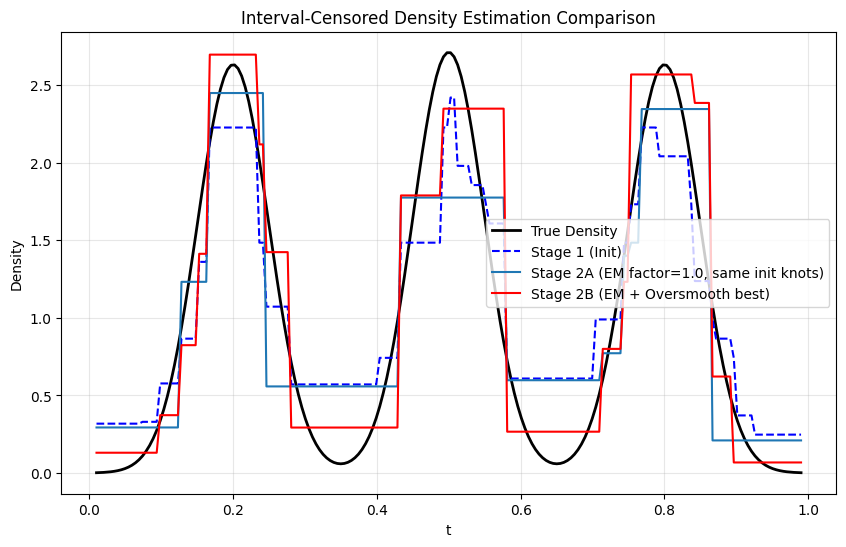

In [27]:
# Get densities from each estimator
grid = np.linspace(0.01, 0.99, 200)

init_density = init_result.estimator.get_density_at_points(grid)

# True “no-oversmooth EM” baseline: factor=1.0 using the Stage-1 tuned estimator as working model
em_factor1_density = em_est_factor1.get_density_at_points(grid)

# EM + oversmooth best
em_oversmooth_density = em_result_oversmooth.estimator.get_density_at_points(grid)

# True density
# true_density = beta.pdf(grid, 2, 5)
true_density = sampler.compute_density(grid)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(grid, true_density, 'k-', lw=2, label='True Density')
plt.plot(grid, init_density, 'b--', lw=1.5, label='Stage 1 (Init)')
plt.plot(grid, em_factor1_density, color='tab:blue', lw=1.5, label='Stage 2A (EM factor=1.0, same init knots)')
plt.plot(grid, em_oversmooth_density, 'r-', lw=1.5, label='Stage 2B (EM + Oversmooth best)')
plt.xlabel('t')
plt.ylabel('Density')
plt.title('Interval-Censored Density Estimation Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
# Compute log-likelihoods (only Stage 1, Stage 2A, Stage 2B)
init_ll = incomplete_loglik_interval(init_result.estimator, data)
em_factor1_ll = incomplete_loglik_interval(em_est_factor1, data)
em_oversmooth_ll = incomplete_loglik_interval(em_result_oversmooth.estimator, data)

print("Log-likelihood Comparison:")
print(f"  Stage 1 (Init):                            {init_ll:.4f}")
print(f"  Stage 2A (EM factor=1.0, same init knots): {em_factor1_ll:.4f}")
print(f"  Stage 2B (EM + Oversmooth best):          {em_oversmooth_ll:.4f}")

Log-likelihood Comparison:
  Stage 1 (Init):                            -818.4861
  Stage 2A (EM factor=1.0, same init knots): -810.0044
  Stage 2B (EM + Oversmooth best):          -795.4497


In [28]:
# --- Evaluation: KL divergence vs true density ---
# Numerically approximates KL(true || est) and KL(est || true) on a fine grid.

import numpy as np
import pandas as pd


def _normalize_on_grid(f: np.ndarray, grid: np.ndarray, eps: float = 1e-15) -> np.ndarray:
    f = np.asarray(f, dtype=float)
    f = np.clip(f, eps, np.inf)
    area = float(np.trapezoid(f, grid))
    return f / area


def kl_divergence(p: np.ndarray, q: np.ndarray, grid: np.ndarray, eps: float = 1e-15) -> float:
    p = np.clip(np.asarray(p, dtype=float), eps, np.inf)
    q = np.clip(np.asarray(q, dtype=float), eps, np.inf)
    return float(np.trapezoid(p * (np.log(p) - np.log(q)), grid))


grid_kl = np.linspace(0.001, 0.999, 10000)

p_true_raw = np.asarray(sampler.compute_density(grid_kl), dtype=float)
p_true = _normalize_on_grid(p_true_raw, grid_kl)

ests = {
    "Stage1(init)": init_result.estimator,
    "Stage 2A (EM factor=1.0, same init knots)": em_est_factor1,
    "Stage 2B (EM + Oversmooth best)": em_result_oversmooth.estimator,
}

rows = []
for name, est in ests.items():
    q_raw = np.asarray(est.get_density_at_points(grid_kl), dtype=float)
    q = _normalize_on_grid(q_raw, grid_kl)

    rows.append({
        "name": name,
        "KL(true || est)": kl_divergence(p_true, q, grid_kl),
        "KL(est || true)": kl_divergence(q, p_true, grid_kl),
        "area_true_raw(trap)": float(np.trapezoid(p_true_raw, grid_kl)),
        "area_est_raw(trap)": float(np.trapezoid(q_raw, grid_kl)),
    })

kl_df = pd.DataFrame(rows).sort_values("KL(true || est)")
display(kl_df)



,name,KL(true || est),KL(est || true),area_true_raw(trap),area_est_raw(trap)
2,Stage 2B (EM + Oversmooth best),0.072096,0.084134,0.999998,1.056108
0,Stage1(init),0.111871,0.206313,0.999998,1.039645
1,"Stage 2A (EM factor=1.0, same init knots)",0.134798,0.207886,0.999998,1.042366


,em_norm_factor,best_oversmooth_factor,incomplete_loglik,KL(true || est),KL(est || true)
0,1.50,0.6,-794.882971,0.086831,0.103710
1,1.65,0.6,-793.277838,0.084861,0.092604
2,1.80,0.6,-792.412988,0.089462,0.087810
3,1.95,0.7,-792.006177,0.106122,0.105994
4,2.10,0.6,-791.813228,0.104495,0.103812
5,2.25,0.6,-791.590592,0.116369,0.114408
6,2.40,0.6,-791.409461,0.129316,0.124383
7,2.55,0.6,-791.355778,0.144154,0.134756
8,2.70,0.6,-791.286186,0.157971,0.143005
9,2.85,0.8,-791.155606,0.161198,0.154942


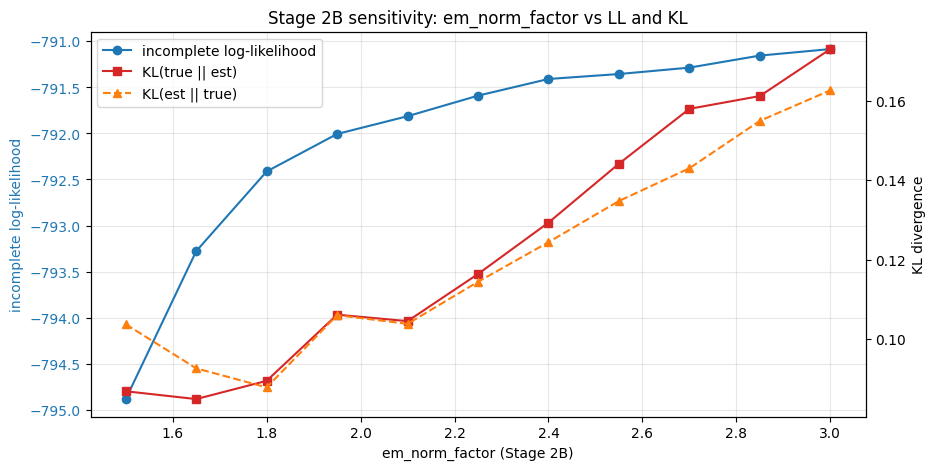

In [25]:
# --- Stage 2B sensitivity: sweep em_norm_factor and track LL + KL ---
# This evaluates Stage 2B only (oversmooth grid search + EM), varying em_norm_factor.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Ensure KL helpers exist (defined earlier in the notebook, but re-define safely)
def _normalize_on_grid(f: np.ndarray, grid: np.ndarray, eps: float = 1e-15) -> np.ndarray:
    f = np.asarray(f, dtype=float)
    f = np.clip(f, eps, np.inf)
    area = float(np.trapezoid(f, grid))
    return f / area


def kl_divergence(p: np.ndarray, q: np.ndarray, grid: np.ndarray, eps: float = 1e-15) -> float:
    p = np.clip(np.asarray(p, dtype=float), eps, np.inf)
    q = np.clip(np.asarray(q, dtype=float), eps, np.inf)
    return float(np.trapezoid(p * (np.log(p) - np.log(q)), grid))


grid_kl = np.linspace(0.001, 0.999, 10000)
p_true_raw = np.asarray(sampler.compute_density(grid_kl), dtype=float)
p_true = _normalize_on_grid(p_true_raw, grid_kl)

em_norm_factors = np.linspace(1.5, 3.0, 11)
rows = []

for enf in em_norm_factors:
    tuner = IntervalCensoredEMTuner(
        data,
        stage1_estimator=init_result.estimator,
        n_grid_points=100,
        do_over_smooth=True,
        oversmooth_factors=[0.6, 0.7, 0.8, 0.9, 1.0],
        em_m_imputations=50,
        em_max_em_iter=20,
        em_tol=1e-3,
        em_norm_factor=float(enf),
        silent=True,
        random_state=42,
    )

    res = tuner.optimize()
    est = res.estimator

    ll = float(incomplete_loglik_interval(est, data))

    q_raw = np.asarray(est.get_density_at_points(grid_kl), dtype=float)
    q = _normalize_on_grid(q_raw, grid_kl)

    best_factor = res.best_params.get("oversmooth_factor", None)

    rows.append({
        "em_norm_factor": float(enf),
        "best_oversmooth_factor": None if best_factor is None else float(best_factor),
        "incomplete_loglik": ll,
        "KL(true || est)": kl_divergence(p_true, q, grid_kl),
        "KL(est || true)": kl_divergence(q, p_true, grid_kl),
    })

sweep_df = pd.DataFrame(rows).sort_values("em_norm_factor")
display(sweep_df)

# Plot: log-likelihood + KL vs em_norm_factor
fig, ax1 = plt.subplots(figsize=(10, 5))

ll_line = ax1.plot(
    sweep_df["em_norm_factor"],
    sweep_df["incomplete_loglik"],
    marker="o",
    color="tab:blue",
    label="incomplete log-likelihood",
)[0]
ax1.set_xlabel("em_norm_factor (Stage 2B)")
ax1.set_ylabel("incomplete log-likelihood", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
kl1_line = ax2.plot(
    sweep_df["em_norm_factor"],
    sweep_df["KL(true || est)"],
    marker="s",
    color="tab:red",
    label="KL(true || est)",
)[0]
kl2_line = ax2.plot(
    sweep_df["em_norm_factor"],
    sweep_df["KL(est || true)"],
    marker="^",
    linestyle="--",
    color="tab:orange",
    label="KL(est || true)",
)[0]
ax2.set_ylabel("KL divergence")

ax2.legend([ll_line, kl1_line, kl2_line], ["incomplete log-likelihood", "KL(true || est)", "KL(est || true)"], loc="best")

plt.title("Stage 2B sensitivity: em_norm_factor vs LL and KL")
plt.show()

